<a href="https://colab.research.google.com/github/Nanda29442/ait-lab/blob/main/Task-7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
def solve_monkey_banana(monkey, box, banana):
    state = {"monkey": monkey, "box": box, "on_box": False, "has_banana": False}
    plan = []
    if state["monkey"] != state["box"]:
        plan.append(f"Go from {state['monkey']} to {state['box']}")
        state["monkey"] = state["box"]
    if state["box"] != banana:
        plan.append(f"Push box from {state['box']} to {banana}")
        state["monkey"] = state["box"] = banana
    if not state["on_box"]:
        plan.append("Climb onto box")
        state["on_box"] = True

    if state["on_box"] and state["monkey"] == banana:
        plan.append("Grasp banana")
        state["has_banana"] = True

    return plan
steps = solve_monkey_banana(monkey="A", box="C", banana="B")

for i, step in enumerate(steps, 1):
    print(f"Step {i}: {step}")

Step 1: Go from A to C
Step 2: Push box from C to B
Step 3: Climb onto box
Step 4: Grasp banana


### Visualizing the Monkey and Banana Problem Solution

This diagram illustrates the steps generated by the `solve_monkey_banana` function. It shows the monkey's and box's positions relative to the banana at each stage of the plan.

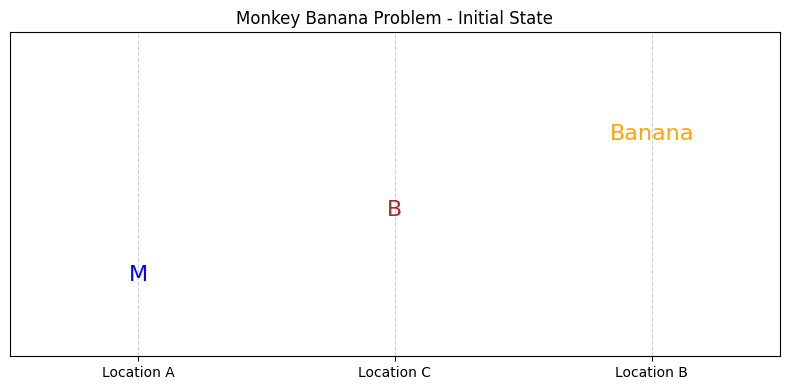

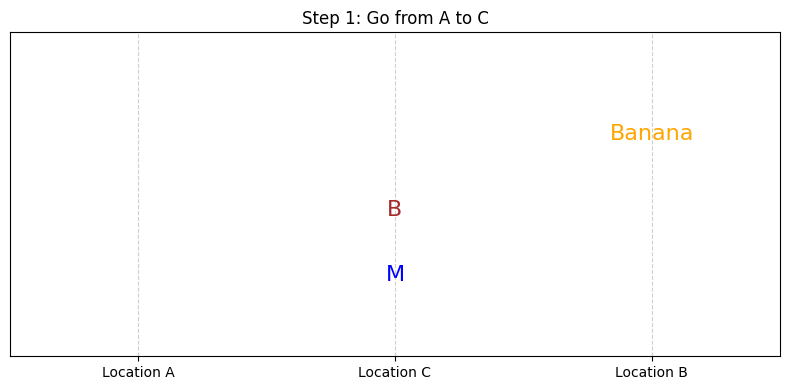

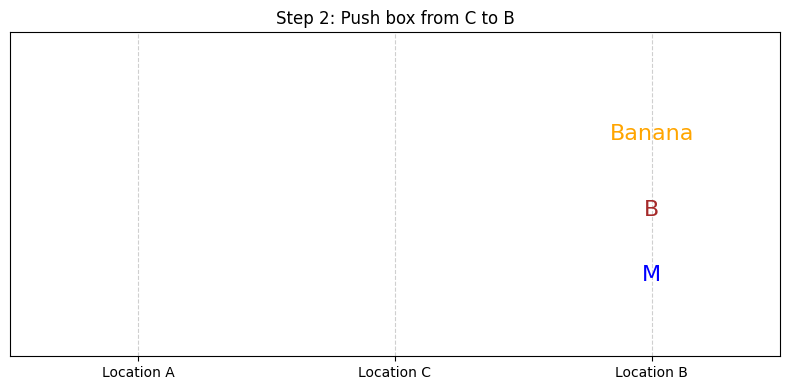

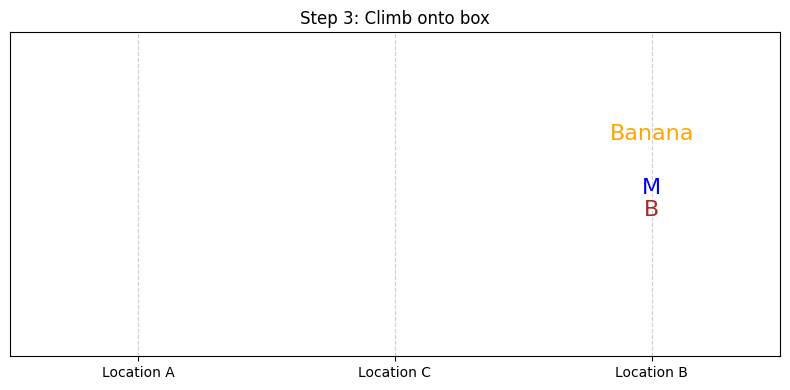

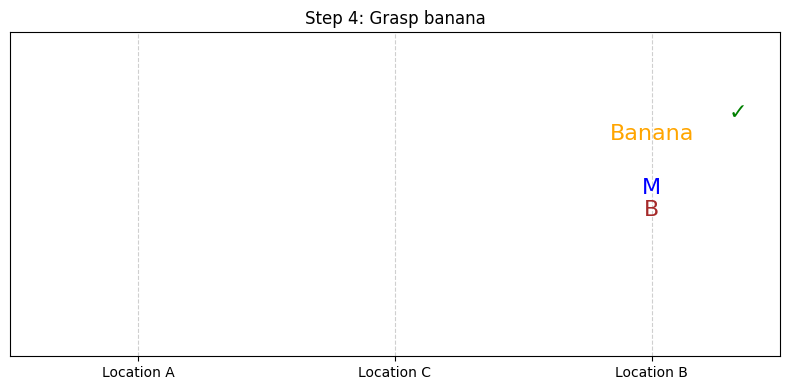

In [8]:
import matplotlib.pyplot as plt

def visualize_steps(initial_monkey, initial_box, initial_banana, steps)
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']
    location_map = {'A': 0, 'B': 2, 'C': 1}
    location_labels = {0: 'Location A', 1: 'Location C', 2: 'Location B'}

    def _draw_single_state(ax, monkey_loc_val, box_loc_val, banana_loc_val, on_box_state, has_banana_state, title_text):
        ax.clear()
        ax.set_xlim(-0.5, 2.5)
        ax.set_ylim(-0.5, 2.5)
        ax.set_xticks(list(location_labels.keys()))
        ax.set_xticklabels([location_labels[k] for k in sorted(location_labels.keys())])
        ax.set_yticks([])
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.set_title(title_text)

        m_y_offset = 0.2
        if on_box_state:
            m_y_offset = 1.0

        ax.text(monkey_loc_val, m_y_offset, 'M', color='blue', fontsize=16, ha='center')
        ax.text(box_loc_val, 0.8, 'B', color='brown', fontsize=16, ha='center')
        ax.text(banana_loc_val, 1.5, 'Banana', fontsize=16, ha='center', color='orange')
        if has_banana_state:
            ax.text(banana_loc_val + 0.3, 1.7, '✓', color='green', fontsize=16)
        fig.tight_layout()
        plt.show()

    current_monkey_loc = initial_monkey
    current_box_loc = initial_box
    on_box = False
    has_banana = False
    fig, ax = plt.subplots(figsize=(8, 4))
    _draw_single_state(ax,
                       location_map[current_monkey_loc],
                       location_map[current_box_loc],
                       location_map[initial_banana],
                       on_box, has_banana,
                       "Monkey Banana Problem - Initial State")
    for i, step in enumerate(steps, 1):
        if "Go from" in step:
            parts = step.split(' ')
            end_loc = parts[4]
            current_monkey_loc = end_loc
        elif "Push box from" in step:
            parts = step.split(' ')
            end_box_loc = parts[5]
            current_monkey_loc = end_box_loc
            current_box_loc = end_box_loc
        elif "Climb onto box" in step:
            on_box = True
        elif "Grasp banana" in step:
            has_banana = True

        fig, ax = plt.subplots(figsize=(8, 4))
        _draw_single_state(ax,
                           location_map[current_monkey_loc],
                           location_map[current_box_loc],
                           location_map[initial_banana],
                           on_box, has_banana,
                           f"Step {i}: {step}")
visualize_steps(initial_monkey="A", initial_box="C", initial_banana="B", steps=steps)